# Eigen-Interactions Filtering

Apply the eigen-interactions package to sequences from the joint library (~57k).

### Steps

1. **Load sequences** from joint library

2. **Compute DeepLIFT/SHAP attributions** $A(s, k)$ for sequence $s$ across $k$ cell lines

3. **Compute Covariance matrix** $\mathbf{C}$ where:

$\displaystyle C_{ij} = \text{Cov}\!\big(A(s, k_i),\; A(s, k_j)\big) = \frac{1}{L}\sum_{\ell=1}^{L} A_\ell(s, k_i)\, A_\ell(s, k_j) \;-\; \bar{A}(s, k_i)\,\bar{A}(s, k_j)$

   - **Diagonal:** $C_{ii} = \text{Var}\!\big(A(s, k_i)\big)$
   - **Off-diagonal:** $C_{ij} = \text{Cov}\!\big(A(s, k_i),\; A(s, k_j)\big),\quad i \neq j$

4. **Find eigen-interactions** by diagonalizing $\mathbf{C}$:

$\displaystyle \mathbf{C} = \mathbf{V}\,\boldsymbol{\Lambda}\,\mathbf{V}^\top \qquad\Longrightarrow\qquad \text{EI}_m(s) = \sum_{k} V_{km}\, A(s, k)$

   so that in the new basis $(\text{EI}_1, \text{EI}_2, \ldots)$ the off-diagonals $\approx 0$.

5. **Plot** all $\text{EI}_1(s)$ projected onto 3D coordinates $(\text{HepG2},\; \text{K562},\; \text{WTC11})$.

In [1]:
import os, sys, importlib
import numpy as np
import pandas as pd

os.environ['CUDA_VISIBLE_DEVICES'] = '0'

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
EIGEN_DIR = os.path.join(REPO, 'eigen-interactions')
sys.path.insert(0, EIGEN_DIR)

import eigen_steering; importlib.reload(eigen_steering)
from eigen_steering import EigenMap, PROMOTER_SEQ, RAND_BARCODE

# Override paths to point at our local models instead of the training repo
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/alphagenome_torch_MPRAMoCon/weights/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')

# Our model dirs have best_stage2.pt directly (no checkpoints/ subdir),
# so patch _load_model to look in the right place
_orig_load = EigenMap._load_model
def _patched_load(self, ct, squeeze=False):
    model_name = self.model_names[ct]
    ckpt_dir = os.path.join(eigen_steering.RESULTS_DIR, model_name)
    # Check both layouts: direct and checkpoints/
    direct = os.path.join(ckpt_dir, 'best_stage2.pt')
    nested = os.path.join(ckpt_dir, 'checkpoints', 'best_stage2.pt')
    if os.path.exists(direct) and not os.path.exists(nested):
        os.makedirs(os.path.join(ckpt_dir, 'checkpoints'), exist_ok=True)
        os.symlink(direct, nested)
    return _orig_load(self, ct, squeeze=squeeze)
EigenMap._load_model = _patched_load

DATA_CSV = os.path.join(REPO, 'data', 'joint_library_combined.csv')
print(f'Eigen-interactions loaded from {EIGEN_DIR}')

AlphaGenome patches applied (all functional activations -> nn.Module).
Eigen-interactions loaded from /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/eigen-interactions


In [2]:
# Load joint library
df = pd.read_csv(DATA_CSV)
df = df.dropna(subset=['sequence', 'K562_log2FC', 'HepG2_log2FC', 'WTC11_log2FC']).reset_index(drop=True)
print(f'{len(df)} sequences with K562 + HepG2 + WTC11 data')

# Best models per cell line by Pearson R on joint library (validate_models.ipynb)
# K562:  do075 → r=0.8915 | do06 → r=0.8837 | do03 → r=0.8683
# HepG2: do03  → r=0.8750 | do075 → r=0.8703 | do06 → r=0.8665
# WTC11: do075 → r=0.8457 | do06 → r=0.8371 | do03 → r=0.8262
MODEL_NAMES = {
    'K562':  'K562_v6_do075',
    'HepG2': 'HepG2_v6_do03',
    'WTC11': 'WTC11_v6_do075',
}

56974 sequences with K562 + HepG2 + WTC11 data


In [5]:
# Load precomputed DeepLIFT/SHAP attributions
# (computed via: bash submit_attributions.sh && bash submit_attributions.sh merge)
import glob

ATTR_PATH = os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz')
SHARD_DIR = os.path.join(REPO, 'genomic_targets', 'data', 'attr_shards')

em = EigenMap(model_names=MODEL_NAMES, device='cuda')
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in MODEL_NAMES})

N_TARGET = len(df)  # 56974

if os.path.exists(ATTR_PATH):
    # Attributions were computed on all rows with valid sequences (56978),
    # but df is filtered to rows with valid seq + all 3 log2FC (56974).
    # WTC11 has 56980 due to reshard overlap — truncate to 56978 first.
    df_full = pd.read_csv(DATA_CSV)
    seq_valid_idx = df_full['sequence'].notna()
    n_seq_valid = seq_valid_idx.sum()  # 56978
    full_valid_idx = df_full[['sequence','K562_log2FC','HepG2_log2FC','WTC11_log2FC']].notna().all(axis=1)
    keep_mask = full_valid_idx[seq_valid_idx].values  # length 56978
    del df_full

    raw = np.load(ATTR_PATH, allow_pickle=False)

    # Manually populate EigenMap
    ohe = em.X.numpy()
    for ct in MODEL_NAMES:
        if f'attr_{ct}' in raw:
            arr = raw[f'attr_{ct}'][:n_seq_valid]   # truncate to 56978 (handles WTC11's 56980)
            hyp = arr[keep_mask]                      # filter to 56974
            em.attr_hyp[ct] = hyp
            em.attr[ct] = hyp * ohe
            em.importance[ct] = em.attr[ct].sum(axis=1)
        if f'predictions_{ct}' in raw:
            em.predictions[ct] = raw[f'predictions_{ct}'][:n_seq_valid][keep_mask]

    print(f'Loaded attributions ({N_TARGET} seqs after filtering)')
    print(f'\nAttribution shapes:')
    for ct in MODEL_NAMES:
        print(f'  {ct}: attr {em.attr[ct].shape}  attr_hyp {em.attr_hyp[ct].shape}')
else:
    print(f'Merged file not found: {ATTR_PATH}')
    print(f'Run: bash submit_attributions.sh merge')
    print(f'\nShard status:')
    for ct in MODEL_NAMES:
        shards = sorted(glob.glob(os.path.join(SHARD_DIR, f'{ct}_shard_*.npz')))
        complete = []
        for s in shards:
            try:
                sz = os.path.getsize(s)
                if sz > 0:
                    np.load(s, allow_pickle=False)
                    complete.append(s)
            except Exception:
                pass
        print(f'  {ct}: {len(complete)}/10 shards complete')

EigenMap: ['K562', 'HepG2', 'WTC11'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03', 'WTC11': 'WTC11_v6_do075'}
Loaded 56974 sequences, X shape: torch.Size([56974, 4, 281])
Loaded attributions (56974 seqs after filtering)

Attribution shapes:
  K562: attr (56974, 4, 281)  attr_hyp (56974, 4, 281)
  HepG2: attr (56974, 4, 281)  attr_hyp (56974, 4, 281)
  WTC11: attr (56974, 4, 281)  attr_hyp (56974, 4, 281)


## Single-sequence eigendecomposition demo

For one sequence, build the importance matrix $E$ (230 positions × 3 cell types), compute the covariance $C = E^T E / L$, and eigendecompose to get 3 eigenvectors in (K562, HepG2, WTC11) space.

In [29]:
# Pick an example sequence
ex_idx = 9

# Eigendecompose just this one sequence
# (eigendecompose loops over all seqs in em, so we make a mini copy)
from copy import deepcopy
em_single = EigenMap(model_names=MODEL_NAMES, device='cpu')
em_single.cell_types = em.cell_types
em_single.X = em.X[ex_idx:ex_idx+1]
em_single.importance = {ct: em.importance[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
em_single.attr = {ct: em.attr[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
em_single.attr_hyp = {ct: em.attr_hyp[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
if em.predictions:
    em_single.predictions = {ct: em.predictions[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}
if em.actual:
    em_single.actual = {ct: em.actual[ct][ex_idx:ex_idx+1] for ct in MODEL_NAMES}

em_single.eigendecompose(enhancer_only=True)
r = em_single.eigen_results[0]

print(f'Sequence {ex_idx}')
print(f'  Covariance matrix C (3x3):')
print(f'    {r["cov"]}')
print(f'  Eigenvalues: {r["eigenvalues"]}')
print(f'  Variance explained: {r["var_ratio"] * 100}')
print(f'  Eigenvectors (columns = EI_1, EI_2, EI_3):')
for ci, ct in enumerate(em.cell_types):
    print(f'    {ct:6s}: {r["eigenvectors"][ci]}')

EigenMap: ['K562', 'HepG2', 'WTC11'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03', 'WTC11': 'WTC11_v6_do075'}
Eigendecomposed 1 sequences (enhancer only, 230bp)
Sequence 9
  Covariance matrix C (3x3):
    [[0.99999994 0.5530578  0.5696454 ]
 [0.5530578  0.99999976 0.31955394]
 [0.5696454  0.31955394 1.0000002 ]]
  Eigenvalues: [1.9696099  0.68065226 0.34973782]
  Variance explained: [65.65366   22.688408  11.6579275]
  Eigenvectors (columns = EI_1, EI_2, EI_3):
    K562  : [-0.6335337   0.01757553 -0.7735154 ]
    HepG2 : [-0.5430081  -0.7222714   0.42832968]
    WTC11 : [-0.5511599  0.6913864  0.4671269]


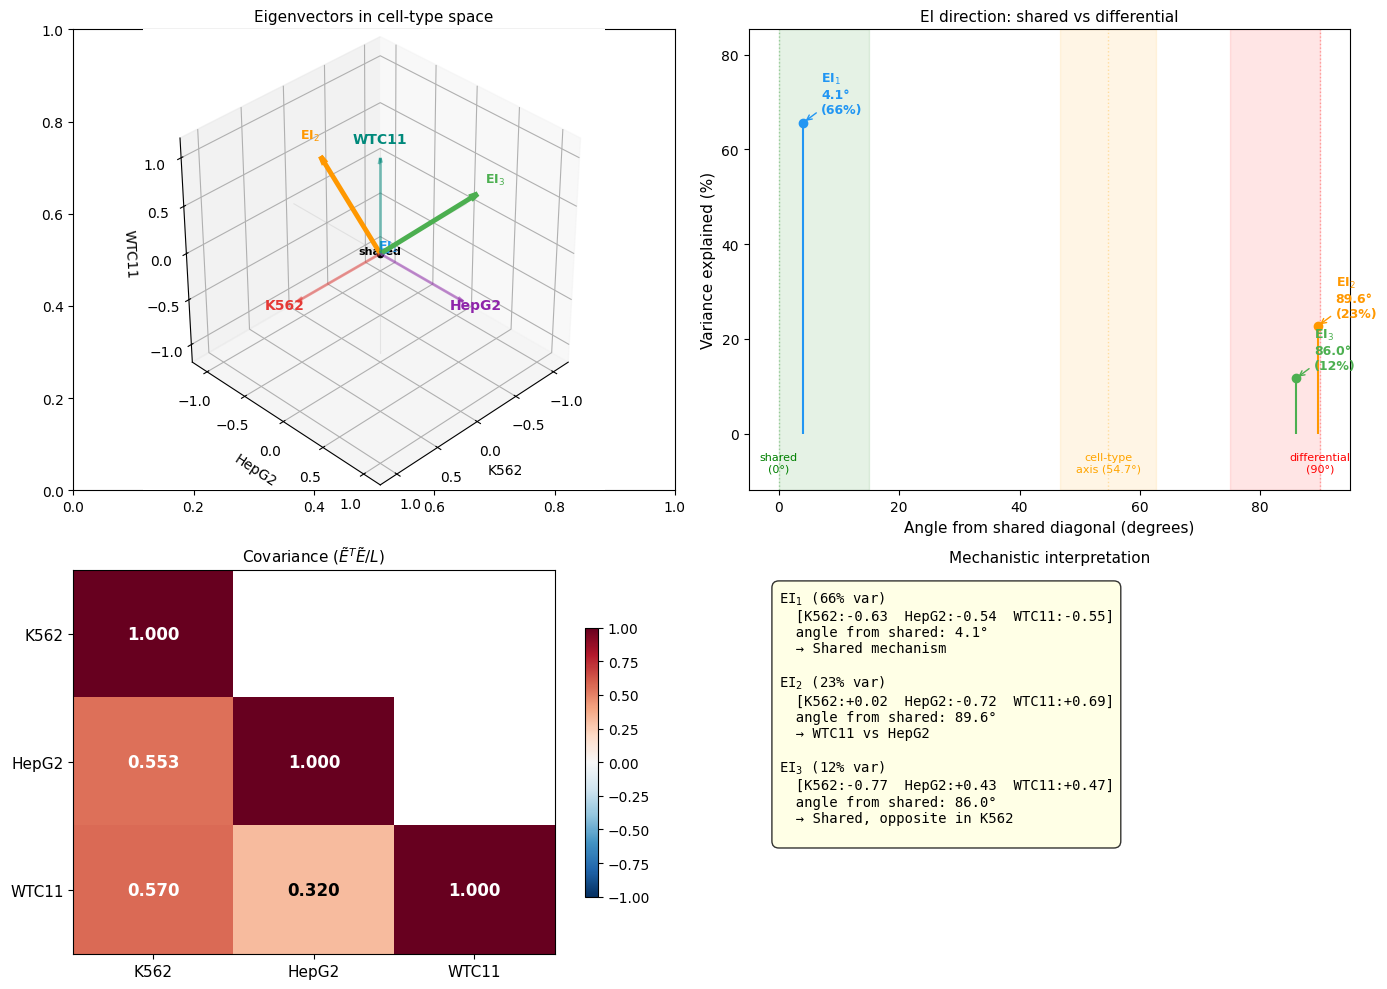

(<Figure size 1800x800 with 4 Axes>,
 array([<Axes: title={'center': 'K562  (eigenvector 1 weight: -0.634)'}>,
        <Axes: title={'center': 'HepG2  (eigenvector 1 weight: -0.543)'}>,
        <Axes: title={'center': 'WTC11  (eigenvector 1 weight: -0.551)'}>,
        <Axes: title={'center': 'Eigenvector 1 = [K562:-0.63, HepG2:-0.54, WTC11:-0.55]  (66% variance)'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)'>],
       dtype=object))

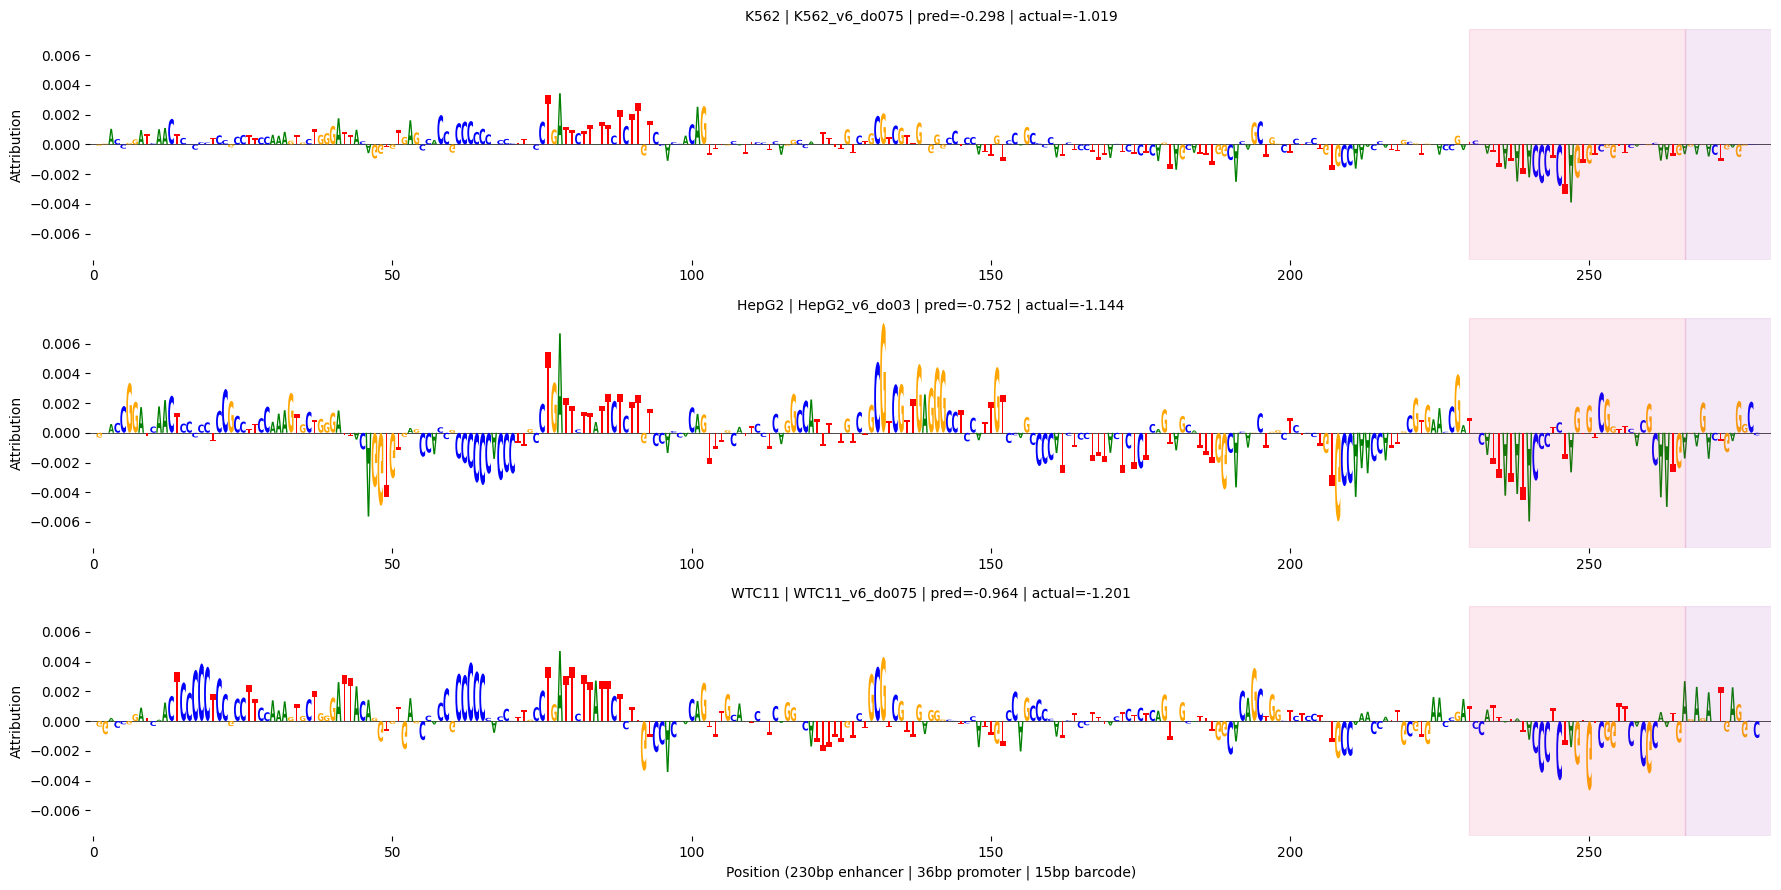

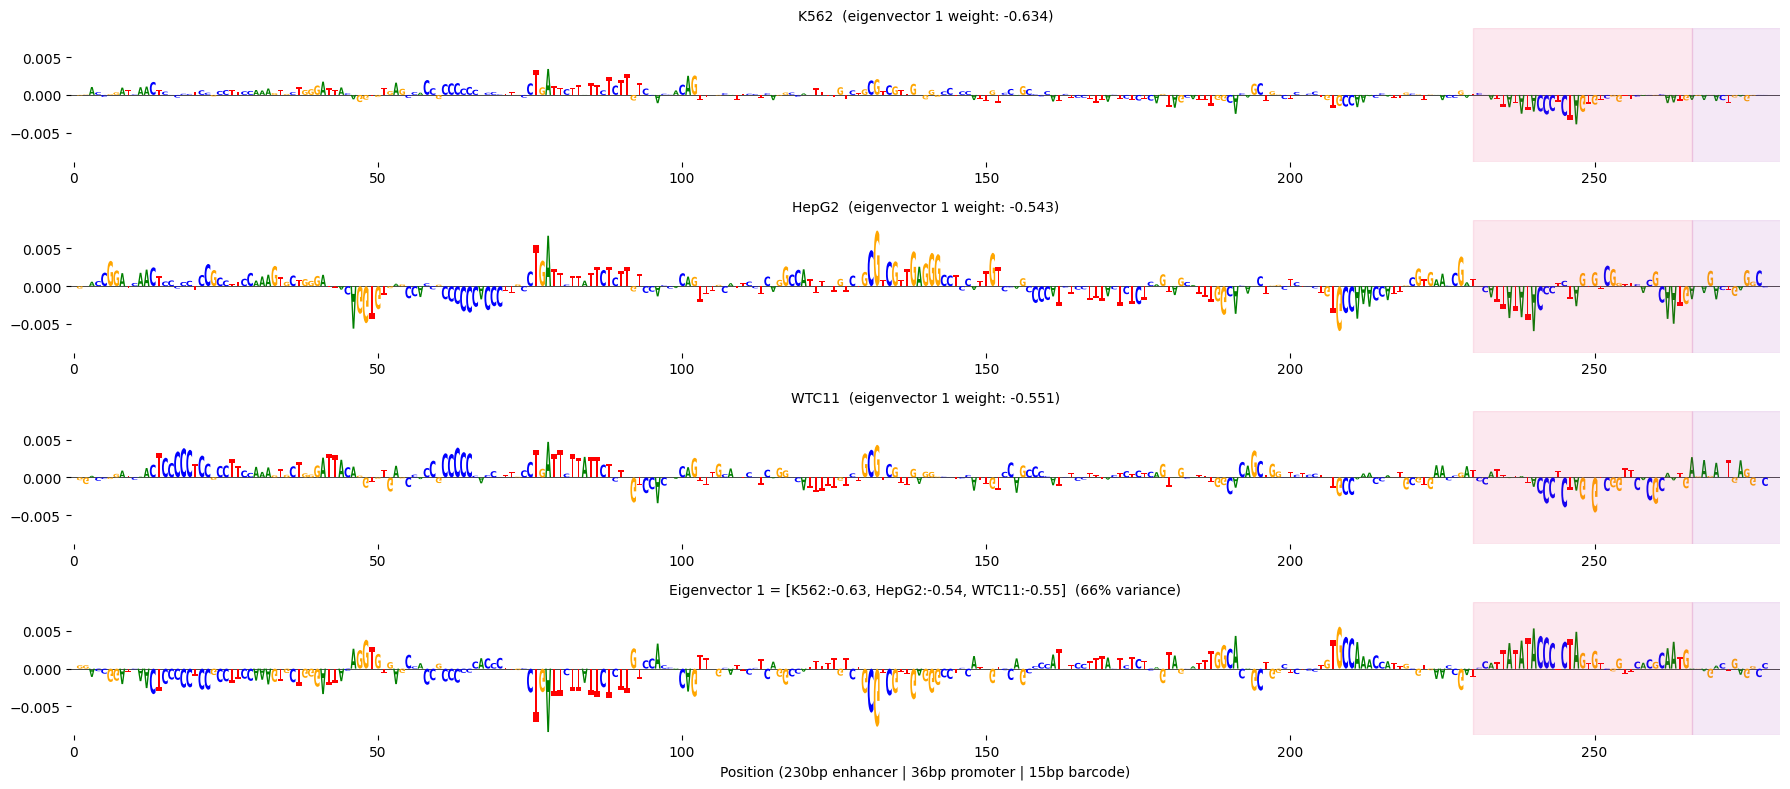

In [31]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

r = em_single.eigen_results[0]
evecs = r['eigenvectors']
evals = r['var_ratio'] * 100
C = r['cov']
ct_names = list(MODEL_NAMES.keys())
ei_colors = ['#2196F3', '#FF9800', '#4CAF50']
ct_colors = ['#E53935', '#8E24AA', '#00897B']

# Reference directions
shared_dir = np.array([1, 1, 1]) / np.sqrt(3)
ct_axes = [np.eye(3)[ci] for ci in range(3)]

# Compute angle (degrees) between each EI and the shared diagonal
def angle_deg(a, b):
    cos = np.clip(np.abs(np.dot(a, b)), 0, 1)  # abs because sign is arbitrary
    return np.degrees(np.arccos(cos))

# Reference: angle from shared diagonal to a single cell-type axis
ref_ct_angle = angle_deg(shared_dir, np.array([1, 0, 0]))  # ~54.7 deg

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1.2, 1]})

# --- Panel 1 (top-left): 3D eigenvectors ---
ax3d = fig.add_subplot(221, projection='3d')

for ci in range(3):
    line = np.zeros((2, 3))
    line[0, ci] = -1.1; line[1, ci] = 1.1
    ax3d.plot(line[:, 0], line[:, 1], line[:, 2],
              color='gray', alpha=0.15, linewidth=0.8)
ax3d.scatter([0], [0], [0], c='k', s=20, zorder=5)

diag = shared_dir
ax3d.plot([-diag[0], diag[0]], [-diag[1], diag[1]], [-diag[2], diag[2]],
          'k--', alpha=0.5, linewidth=2)
ax3d.text(diag[0]*1.15, diag[1]*1.15, diag[2]*1.15, 'shared',
          fontsize=8, ha='center', color='black', fontweight='bold')

for ci in range(3):
    e = np.zeros(3); e[ci] = 1.0
    ax3d.quiver(0, 0, 0, e[0], e[1], e[2],
                color=ct_colors[ci], alpha=0.5, arrow_length_ratio=0.06,
                linewidth=2)
    ax3d.text(*(e * 1.15), ct_names[ci], fontsize=10, color=ct_colors[ci],
              fontweight='bold', ha='center')

for ei in range(3):
    v = evecs[:, ei]
    ax3d.quiver(0, 0, 0, v[0], v[1], v[2],
                color=ei_colors[ei], arrow_length_ratio=0.08, linewidth=3.5)
    ax3d.text(v[0]*1.18, v[1]*1.18, v[2]*1.18,
              f'EI$_{ei+1}$', fontsize=9, fontweight='bold',
              color=ei_colors[ei], ha='center')

ax3d.set_xlim(-1.2, 1.2); ax3d.set_ylim(-1.2, 1.2); ax3d.set_zlim(-1.2, 1.2)
ax3d.set_xlabel('K562'); ax3d.set_ylabel('HepG2'); ax3d.set_zlabel('WTC11')
ax3d.set_title('Eigenvectors in cell-type space', fontsize=11)
ax3d.set_box_aspect([1, 1, 1])
ax3d.view_init(elev=35.26, azim=45)

# --- Panel 2 (top-right): Angle from shared diagonal ---
ax = axes[0][1]

# Angle range: 0° = shared, 54.7° = cell-type axis, 90° = purely differential
ei_angles = [angle_deg(evecs[:, ei], shared_dir) for ei in range(3)]

# Draw reference zones
ax.axvspan(0, 15, alpha=0.1, color='green', label='shared zone')
ax.axvspan(ref_ct_angle - 8, ref_ct_angle + 8, alpha=0.1, color='orange',
           label='cell-specific zone')
ax.axvspan(75, 90, alpha=0.1, color='red', label='differential zone')

# Reference lines
ax.axvline(0, color='green', alpha=0.3, linewidth=1, linestyle=':')
ax.axvline(ref_ct_angle, color='orange', alpha=0.3, linewidth=1, linestyle=':')
ax.axvline(90, color='red', alpha=0.3, linewidth=1, linestyle=':')

# EI peaks as stems
for ei in range(3):
    ax.stem([ei_angles[ei]], [evals[ei]], linefmt=ei_colors[ei],
            markerfmt='o', basefmt=' ')
    ax.annotate(f'EI$_{ei+1}$\n{ei_angles[ei]:.1f}°\n({evals[ei]:.0f}%)',
                xy=(ei_angles[ei], evals[ei]),
                xytext=(ei_angles[ei] + 3, evals[ei] + 2),
                fontsize=9, fontweight='bold', color=ei_colors[ei],
                arrowprops=dict(arrowstyle='->', color=ei_colors[ei], lw=1))

# Reference labels
ax.text(0, -8, 'shared\n(0°)', ha='center', fontsize=8, color='green')
ax.text(ref_ct_angle, -8, f'cell-type\naxis ({ref_ct_angle:.1f}°)',
        ha='center', fontsize=8, color='orange')
ax.text(90, -8, 'differential\n(90°)', ha='center', fontsize=8, color='red')

ax.set_xlim(-5, 95)
ax.set_ylim(-12, max(evals) * 1.3)
ax.set_xlabel('Angle from shared diagonal (degrees)', fontsize=11)
ax.set_ylabel('Variance explained (%)', fontsize=11)
ax.set_title('EI direction: shared vs differential', fontsize=11)

# --- Panel 3 (bottom-left): Covariance matrix (lower triangle) ---
ax = axes[1][0]
vmax = np.abs(C).max()
C_masked = np.copy(C).astype(float)
mask_upper = np.triu(np.ones_like(C, dtype=bool), k=1)
C_masked[mask_upper] = np.nan
im = ax.imshow(C_masked, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(ct_names, fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(ct_names, fontsize=11)
for i in range(3):
    for j in range(3):
        if j <= i:
            ax.text(j, i, f'{C[i,j]:.3f}', ha='center', va='center',
                    fontsize=12, fontweight='bold',
                    color='white' if abs(C[i,j]) > 0.5 * vmax else 'black')
ax.set_title('Covariance ($\\tilde{E}^T \\tilde{E} / L$)', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.7)

# --- Panel 4 (bottom-right): Interpretation text box ---
ax = axes[1][1]
ax.axis('off')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('Mechanistic interpretation', fontsize=11)

lines = []
for ei in range(3):
    v = evecs[:, ei]
    pos = [ci for ci in range(3) if v[ci] > 0.1]
    neg = [ci for ci in range(3) if v[ci] < -0.1]
    if len(pos) == 3 or len(neg) == 3:
        mech = 'Shared mechanism'
    elif len(pos) == 2 and len(neg) == 1:
        mech = f'Shared, opposite in {ct_names[neg[0]]}'
    elif len(neg) == 2 and len(pos) == 1:
        mech = f'{ct_names[pos[0]]}-specific'
    elif len(pos) == 1 and len(neg) == 1:
        mech = f'{ct_names[pos[0]]} vs {ct_names[neg[0]]}'
    else:
        mech = 'Mixed'

    weight_str = '  '.join(f'{ct_names[ci]}:{v[ci]:+.2f}' for ci in range(3))
    lines.append(f'EI$_{ei+1}$ ({evals[ei]:.0f}% var)')
    lines.append(f'  [{weight_str}]')
    lines.append(f'  angle from shared: {ei_angles[ei]:.1f}\u00b0')
    lines.append(f'  \u2192 {mech}')
    lines.append('')

ax.text(0.05, 0.95, '\n'.join(lines), transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Attribution logos + EI_1 weighted logo
em_single.plot_attr_logos(seq_idx=0)
em_single.plot_eigen_logos(seq_idx=0)

## Full library eigendecomposition

Eigendecompose all ~57K sequences. For each sequence we get:
- **EI_1 eigenvector**: the dominant mode of cross-cell-type variation (weights in K562/HepG2/WTC11 space)
- **EI_1 eigenvalue / variance ratio**: how much of the positional covariance is explained by the first mode

We can then use EI_1 eigenvector directions to filter for sequences with specific regulatory patterns (e.g. shared vs cell-type-specific enhancers).

In [ ]:
# Eigendecompose the full library
em.eigendecompose(enhancer_only=True)

# Extract EI_1 eigenvectors and variance ratios for all sequences
ei1_vecs = np.array([r['eigenvectors'][:, 0] for r in em.eigen_results])  # (N, 3)
ei1_var = np.array([r['var_ratio'][0] for r in em.eigen_results])          # (N,)

# Add to dataframe for filtering
for ci, ct in enumerate(em.cell_types):
    df[f'EI1_{ct}'] = ei1_vecs[:, ci]
df['EI1_var_explained'] = ei1_var

print(f'EI_1 eigenvectors: {ei1_vecs.shape}')
print(f'EI_1 variance explained: mean={ei1_var.mean():.1%}, median={np.median(ei1_var):.1%}')
print(f'\nEI_1 weight distributions:')
for ci, ct in enumerate(em.cell_types):
    w = ei1_vecs[:, ci]
    print(f'  {ct}: mean={w.mean():.3f}, std={w.std():.3f}, range=[{w.min():.3f}, {w.max():.3f}]')

(<Figure size 1800x900 with 3 Axes>,
 array([<Axes: title={'center': 'K562 | K562_v6_do075 | pred=-0.369 | actual=-0.217'}, ylabel='Attribution'>,
        <Axes: title={'center': 'HepG2 | HepG2_v6_do03 | pred=0.195 | actual=0.003'}, ylabel='Attribution'>,
        <Axes: title={'center': 'WTC11 | WTC11_v6_do075 | pred=-1.292 | actual=-0.462'}, xlabel='Position (230bp enhancer | 36bp promoter | 15bp barcode)', ylabel='Attribution'>],
       dtype=object))

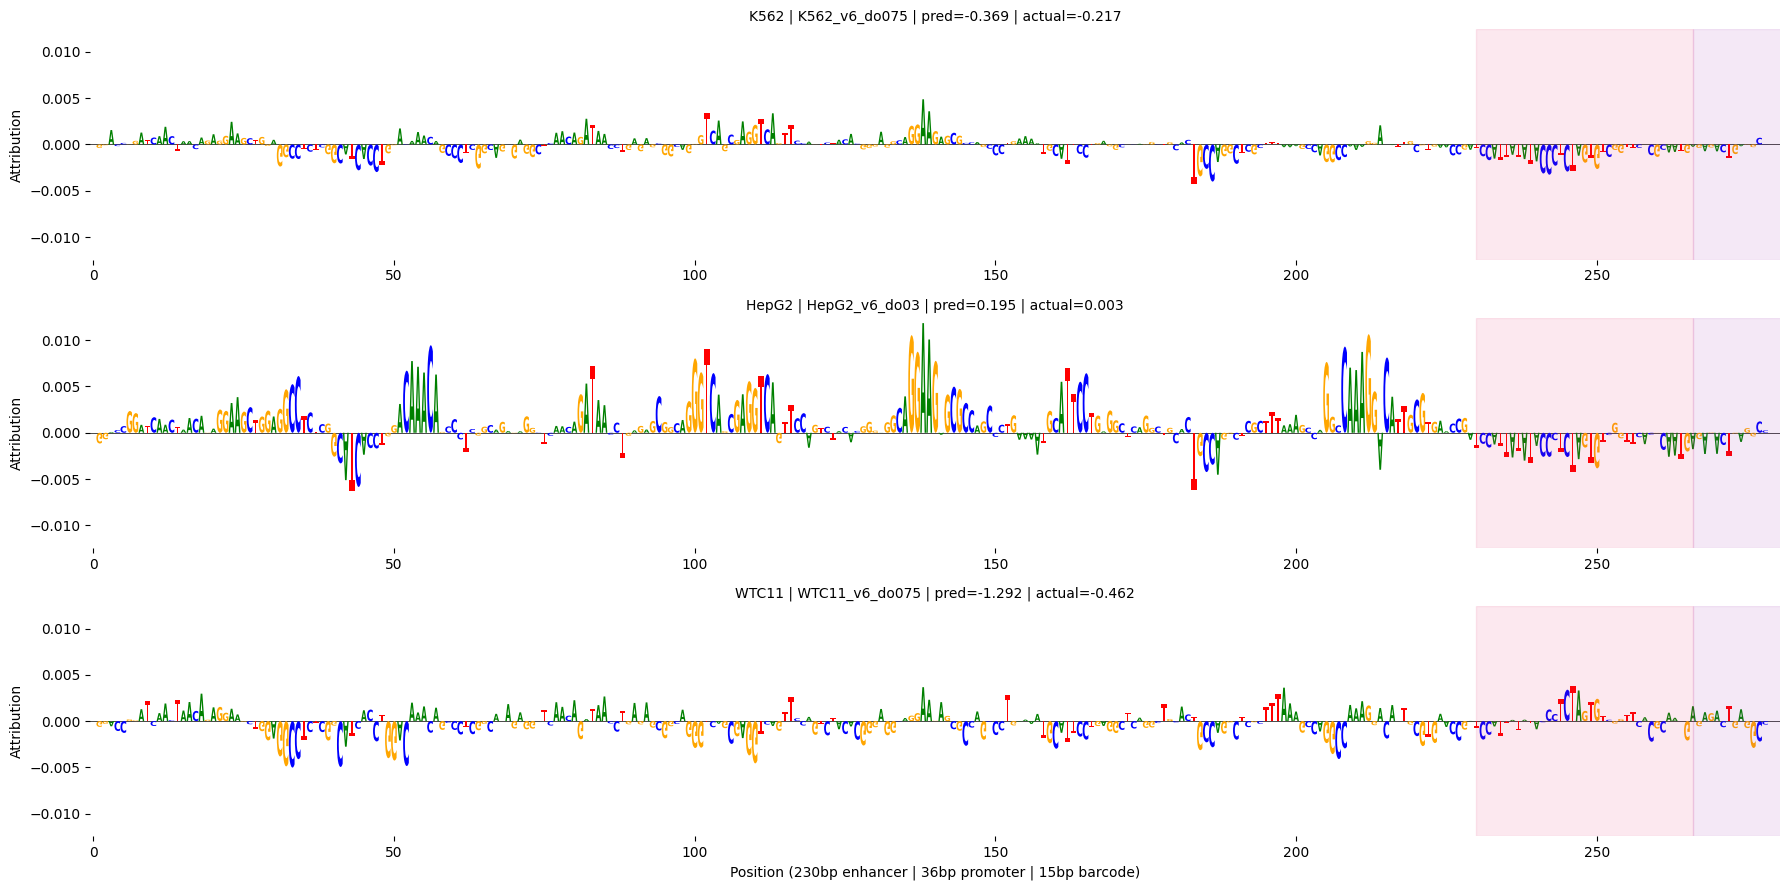

In [7]:
em.plot_attr_logos(seq_idx=1)